In this notebook, we make explicit the relationship between the clusters and the time of creation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as scp
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid.inset_locator import inset_axes
import matplotlib.patches as mpatches

# Global

In [2]:
adata = scp.read("results/QC.h5ad")

## UMAP with time projections

We project our data of each time point over the whole structure.

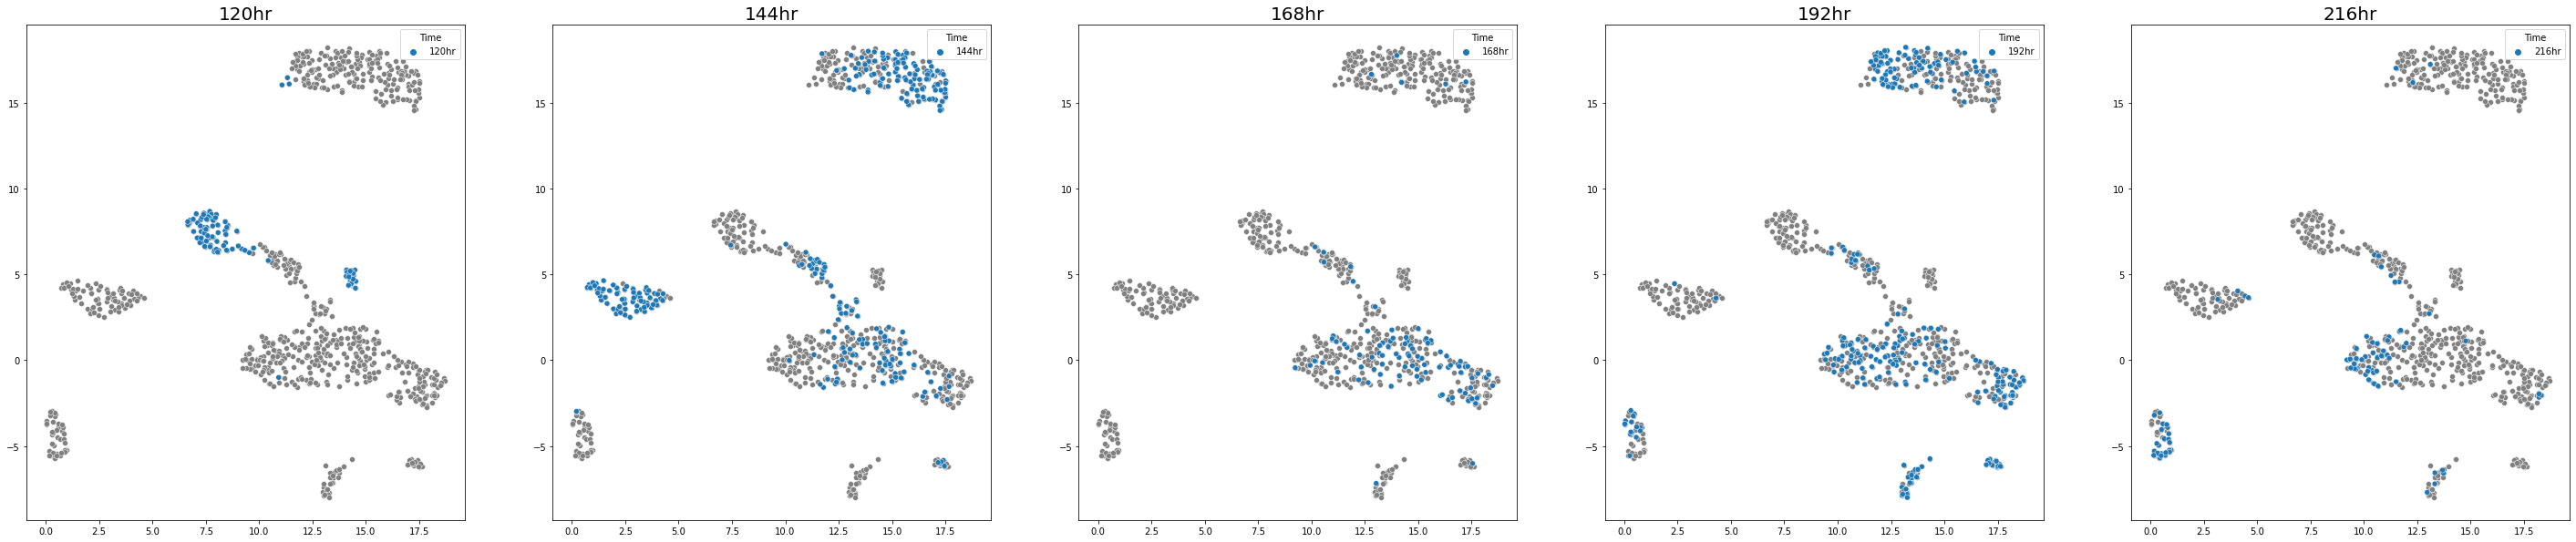

In [3]:
fig,ax = plt.subplots(1,5,figsize=[50,10])

for j,i in enumerate(np.sort(adata.obs["Time"].unique())):
    sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],color="grey",ax=ax[j])
    sns.scatterplot(x=adata[adata.obs["Time"]==i].obsm["X_umap"][:,0],
                    y=adata[adata.obs["Time"]==i].obsm["X_umap"][:,1],
                    hue=adata[adata.obs["Time"]==i].obs["Time"],ax=ax[j])
    ax[j].set_title(i,fontsize=20)
    
fig.savefig("plots/global/UMAP_sep_times.png")

## Cluster relationship

We connect the clusters using the PAGA algorithm and show the time contribution to each clusters in a pie plot overlayed over the UMAP plot.

In [4]:
scp.tl.paga(adata,groups="leiden_global")

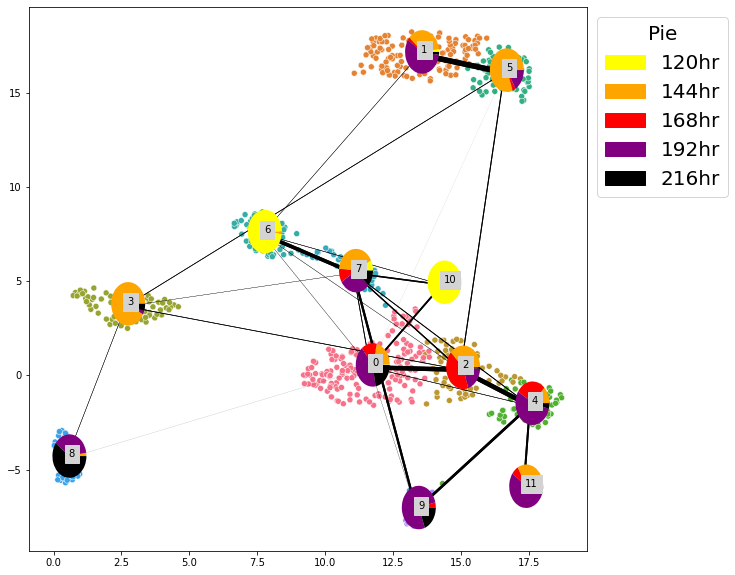

In [5]:
weight = adata.uns["paga"]["connectivities"].todense()

fig,ax = plt.subplots(figsize=[10,10])
# Plots
sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],hue=adata.obs["leiden_global"])
# Line weights
for i,origin in enumerate(adata.obs["leiden_global"].cat.categories.values):
    for j,target in enumerate(adata.obs["leiden_global"].cat.categories.values):
        x1,y1=adata[adata.obs["leiden_global"]==origin].obsm["X_umap"].mean(axis=0)
        x2,y2=adata[adata.obs["leiden_global"]==target].obsm["X_umap"].mean(axis=0)
        
        ax.plot([x1,x2],[y1,y2],linewidth=10*weight[i,j],color="black")

for i,origin in enumerate(adata.obs["leiden_global"].cat.categories.values):
        xmin,ymin = adata.obsm["X_umap"].min(axis=0)
        xmax,ymax = adata.obsm["X_umap"].max(axis=0)
        x1,y1=adata[adata.obs["leiden_global"]==origin].obsm["X_umap"].mean(axis=0)
        subax = ax.inset_axes([(x1-xmin)/(xmax-xmin)/1.1,(y1-ymin)/(ymax-ymin)/1.1,.1,.1])

        m = adata[adata.obs["leiden_global"]==origin].obs.groupby("Time").count().loc[:,"Cell"]
        color = {"120hr":"yellow","144hr":"orange","168hr":"red","192hr":"purple","216hr":"black"}
        cat = m.index
        c = [color[i] for i in m.index]
        subax.pie(m.values,colors=c)
        subax.text(-0.05,-0.05,origin,backgroundcolor="lightgrey",fontsize=10)
        
        yellow_patch = mpatches.Patch(color='yellow', label='120hr')
        orange_patch = mpatches.Patch(color='orange', label='144hr')
        red_patch = mpatches.Patch(color='red', label='168hr')
        purple_patch = mpatches.Patch(color='purple', label='192hr')
        black_patch = mpatches.Patch(color='black', label='216hr')
        ax.legend(title="Pie",bbox_to_anchor=(1,1), loc="upper left",fontsize=20,title_fontsize=20,handles=[yellow_patch,orange_patch,red_patch,purple_patch,black_patch])
        
fig.savefig("plots/global/Clusters_connected_global.png")

## Time causality

For each cluster of the data, we split it in subclusters by time contributions and connect each subclusters through PAGA algorithm maintaining only the connections between neighbour time points and at all time points between whole gastruloid measures (at 144 and 192 hours). This makes explicit the causal connection between clusters between time points and keeps cluster connection between clusters that may not exits at all times because of sorting.

The plot is normalized so the sum of the clusters (rows sum up to one), to make explicit the contribution at each time.

In [6]:
adata.obs["leiden_global_time"] = [j+"_"+i for i,j in zip(adata.obs.loc[:,"leiden_global"].values,adata.obs.loc[:,"Time"].values)]

In [7]:
scp.tl.paga(adata,groups="leiden_global_time")

... storing 'leiden_global_time' as categorical


In [8]:
data = adata.obs.groupby(["leiden_global","Time"]).count().iloc[:,0].unstack()
data = (data.transpose()/data.transpose().sum(axis=0)).transpose()
data = data.stack().reset_index()
#data

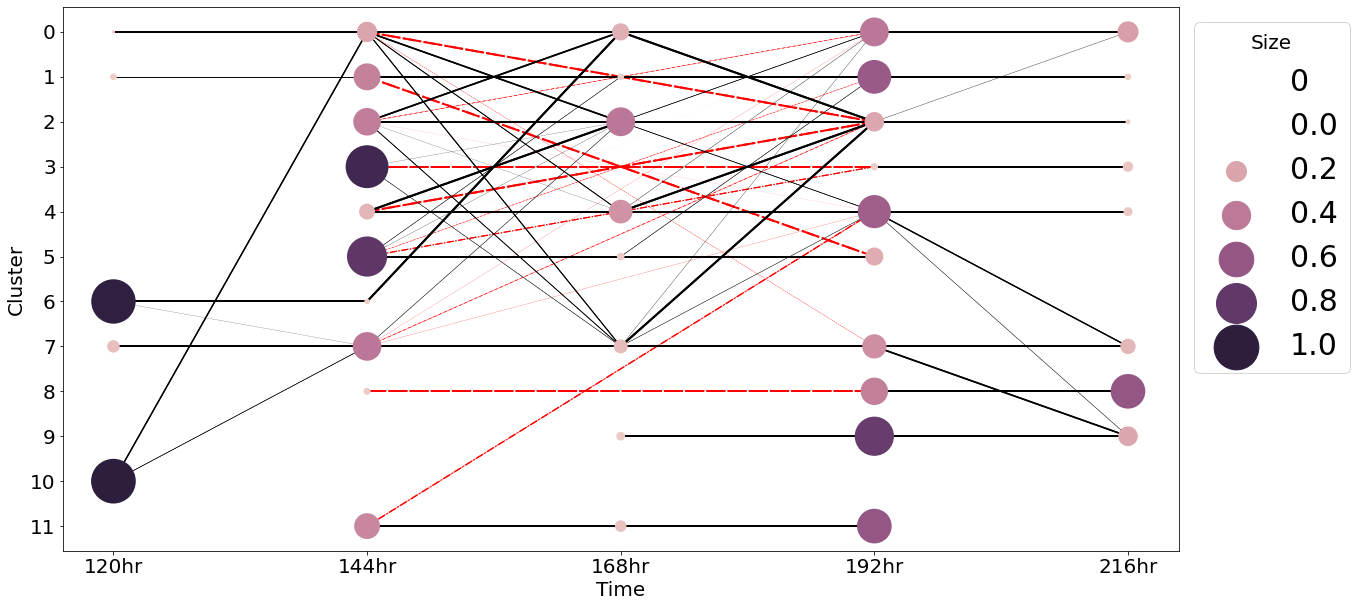

In [9]:
fig,ax=plt.subplots(figsize=[20,10])

weight = adata.uns["paga"]["connectivities"].todense()

xx = {"120hr":0,"144hr":1,"168hr":2,"192hr":3,"216hr":4}
for i,origin in enumerate(adata.obs["leiden_global_time"].cat.categories.values):
    for j,target in enumerate(adata.obs["leiden_global_time"].cat.categories.values):
        x1 = xx[origin.split("_")[0]]
        y1 = np.linspace(0,11,12)[int(origin.split("_")[1])]
        x2 = xx[target.split("_")[0]]
        y2 = np.linspace(0,11,12)[int(target.split("_")[1])]
        
        if x1 == x2+1 or x1 == x2-1:
            ax.plot([x1,x2],[y1,y2],linewidth=2*weight[i,j],color="black",zorder=-2)

        if ((x1==1 and x2 == 3) or (x1==3 and x2 == 1)):
            ax.plot([x1,x2],[y1,y2],linewidth=2*weight[i,j],color="red",linestyle="-.",zorder=-3)
            
sns.scatterplot(data=data,y="leiden_global",x="Time",hue=0,size=0,sizes=(0,2000),alpha=1,ax=ax)
ax.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=30,title="Size",title_fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlabel("Time",fontsize=20)
ax.set_ylabel("Cluster",fontsize=20)

fig.savefig("plots/global/Clusters_reconstructed_by_times.png")

fig.show()

# Sorted

In [10]:
adata = scp.read("results/subSamples/sorted/sorted.h5ad")

## UMAP with time projections

We project our data of each time point over the whole structure.

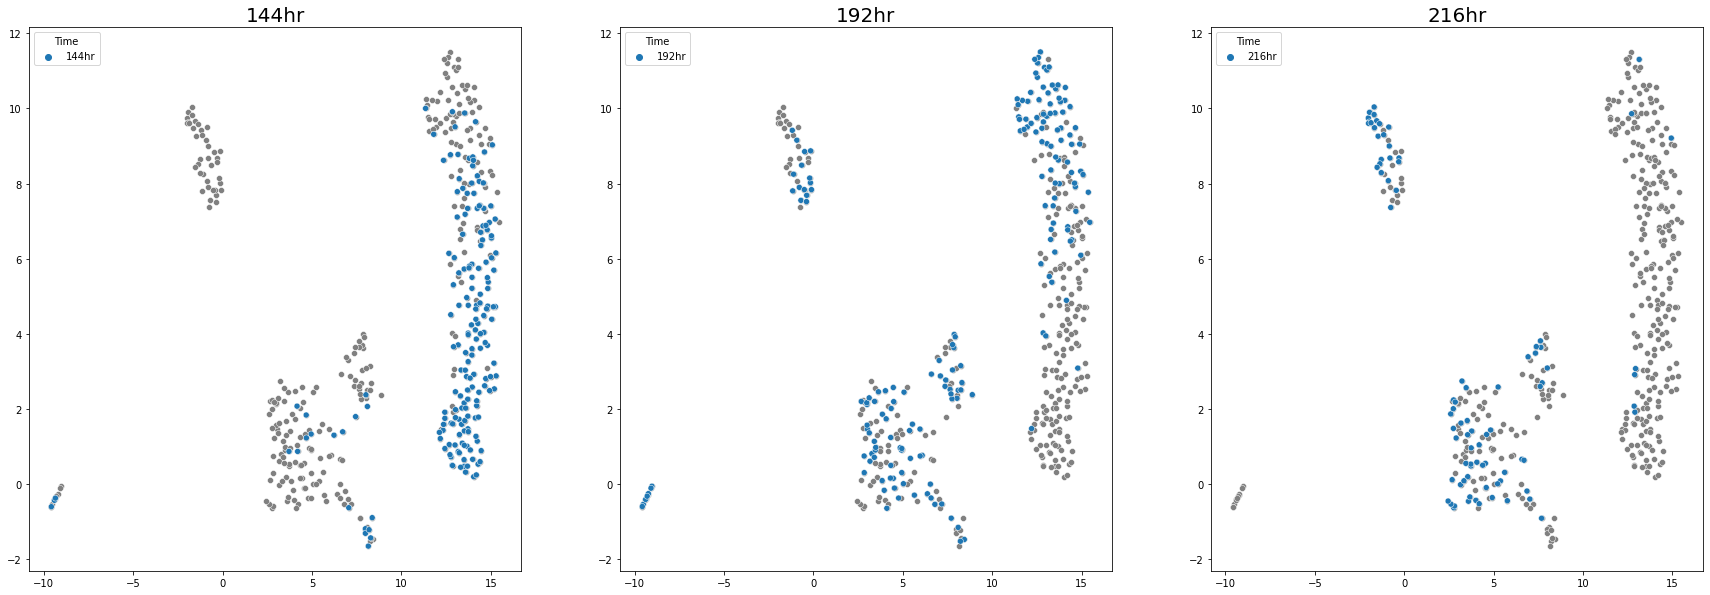

In [11]:
fig,ax = plt.subplots(1,3,figsize=[30,10])

for j,i in enumerate(np.sort(adata.obs["Time"].unique())):
    sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],color="grey",ax=ax[j])
    sns.scatterplot(x=adata[adata.obs["Time"]==i].obsm["X_umap"][:,0],
                    y=adata[adata.obs["Time"]==i].obsm["X_umap"][:,1],
                    hue=adata[adata.obs["Time"]==i].obs["Time"],ax=ax[j])
    ax[j].set_title(i,fontsize=20)
    
fig.savefig("plots/sorted/UMAP_sep_times.png")

## Cluster relationship

We connect the clusters using the PAGA algorithm and show the time contribution to each clusters in a pie plot overlayed over the UMAP plot.

In [12]:
scp.tl.paga(adata,groups="leiden_global")

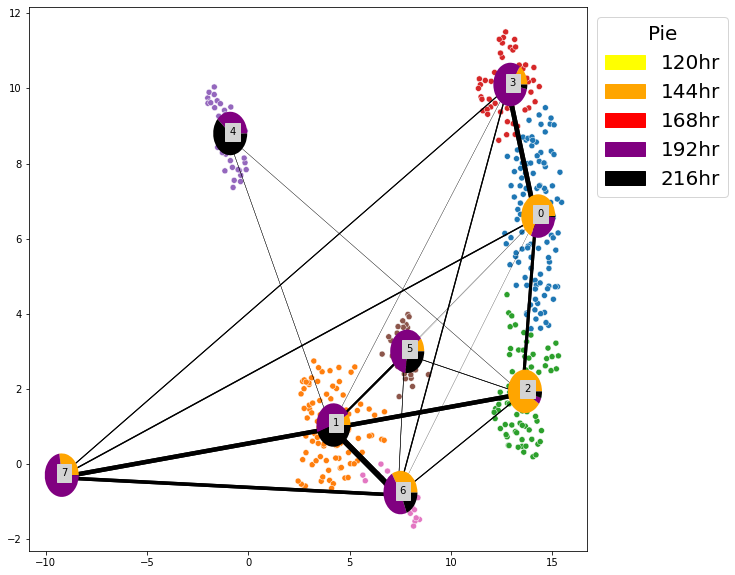

In [13]:
weight = adata.uns["paga"]["connectivities"].todense()

fig,ax = plt.subplots(figsize=[10,10])
# Plots
sns.scatterplot(x=adata.obsm["X_umap"][:,0],y=adata.obsm["X_umap"][:,1],hue=adata.obs["leiden_global"])
# Line weights
for i,origin in enumerate(adata.obs["leiden_global"].cat.categories.values):
    for j,target in enumerate(adata.obs["leiden_global"].cat.categories.values):
        x1,y1=adata[adata.obs["leiden_global"]==origin].obsm["X_umap"].mean(axis=0)
        x2,y2=adata[adata.obs["leiden_global"]==target].obsm["X_umap"].mean(axis=0)
        
        ax.plot([x1,x2],[y1,y2],linewidth=10*weight[i,j],color="black")

for i,origin in enumerate(adata.obs["leiden_global"].cat.categories.values):
        xmin,ymin = adata.obsm["X_umap"].min(axis=0)
        xmax,ymax = adata.obsm["X_umap"].max(axis=0)
        x1,y1=adata[adata.obs["leiden_global"]==origin].obsm["X_umap"].mean(axis=0)
        subax = ax.inset_axes([(x1-xmin)/(xmax-xmin)/1.1,(y1-ymin)/(ymax-ymin)/1.1,.1,.1])

        m = adata[adata.obs["leiden_global"]==origin].obs.groupby("Time").count().loc[:,"Cell"]
        color = {"120hr":"yellow","144hr":"orange","168hr":"red","192hr":"purple","216hr":"black"}
        cat = m.index
        c = [color[i] for i in m.index]
        subax.pie(m.values,colors=c)
        subax.text(-0.05,-0.05,origin,backgroundcolor="lightgrey",fontsize=10)
        
        yellow_patch = mpatches.Patch(color='yellow', label='120hr')
        orange_patch = mpatches.Patch(color='orange', label='144hr')
        red_patch = mpatches.Patch(color='red', label='168hr')
        purple_patch = mpatches.Patch(color='purple', label='192hr')
        black_patch = mpatches.Patch(color='black', label='216hr')
        ax.legend(title="Pie",bbox_to_anchor=(1,1), loc="upper left",fontsize=20,title_fontsize=20,handles=[yellow_patch,orange_patch,red_patch,purple_patch,black_patch])
        
fig.savefig("plots/sorted/Clusters_connected_global.png")

## Time causality

For each cluster of the data, we split it in subclusters by time contributions and connect each subclusters through PAGA algorithm maintaining only the connections between neighbour time points and at all time points between whole gastruloid measures (at 144 and 192 hours). This makes explicit the causal connection between clusters between time points and keeps cluster connection between clusters that may not exits at all times because of sorting.

The plot is normalized so the sum of the clusters (rows sum up to one), to make explicit the contribution at each time.

In [14]:
adata.obs["leiden_global_time"] = [j+"_"+i for i,j in zip(adata.obs.loc[:,"leiden_global"].values,adata.obs.loc[:,"Time"].values)]

In [15]:
scp.tl.paga(adata,groups="leiden_global_time")

... storing 'leiden_global_time' as categorical


In [16]:
data = adata.obs.groupby(["leiden_global","Time"]).count().iloc[:,0].unstack()
data = (data.transpose()/data.transpose().sum(axis=0)).transpose()
data = data.stack().reset_index()
#data

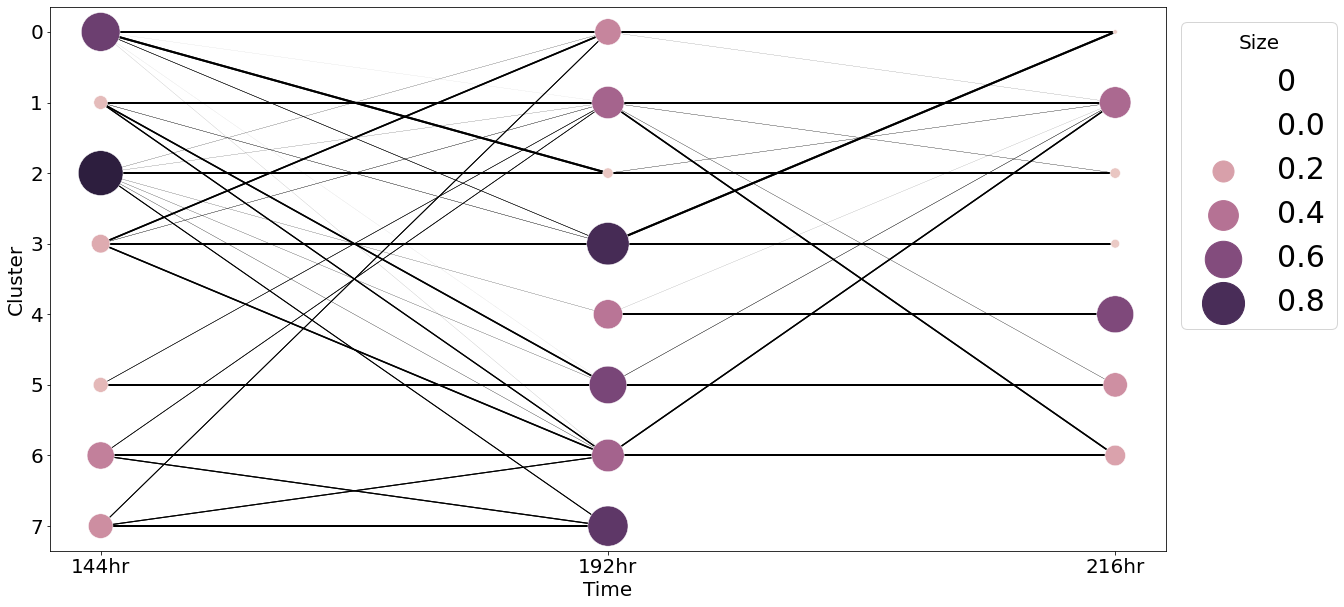

In [17]:
fig,ax=plt.subplots(figsize=[20,10])

weight = adata.uns["paga"]["connectivities"].todense()

xx = {"144hr":0,"192hr":1,"216hr":2}
for i,origin in enumerate(adata.obs["leiden_global_time"].cat.categories.values):
    for j,target in enumerate(adata.obs["leiden_global_time"].cat.categories.values):
        x1 = xx[origin.split("_")[0]]
        y1 = np.linspace(0,11,12)[int(origin.split("_")[1])]
        x2 = xx[target.split("_")[0]]
        y2 = np.linspace(0,11,12)[int(target.split("_")[1])]
        
        if x1 == x2+1 or x1 == x2-1:
            ax.plot([x1,x2],[y1,y2],linewidth=2*weight[i,j],color="black",zorder=-2)

        if ((x1==1 and x2 == 3) or (x1==3 and x2 == 1)):
            ax.plot([x1,x2],[y1,y2],linewidth=2*weight[i,j],color="red",linestyle="-.",zorder=-3)
            
sns.scatterplot(data=data,y="leiden_global",x="Time",hue=0,size=0,sizes=(0,2000),alpha=1,ax=ax)
ax.legend(bbox_to_anchor=(1,1), loc="upper left",fontsize=30,title="Size",title_fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlabel("Time",fontsize=20)
ax.set_ylabel("Cluster",fontsize=20)

fig.savefig("plots/sorted/Clusters_reconstructed_by_times.png")

fig.show()